# Задание 2. Кто в соцсети «связующее звено» — центральность

**Задача** (из «ИСиТ пр.pdf», задание № 2): взять членов группы, собрать их **друзей и друзей-друзей**, и определить, какие члены группы самые **центральные** в этой сети — по трём меркам: **по посредничеству**, **по близости**, **по собственному вектору**.

**Данные.** Реальный VK для нашей группы недоступен (нет API-токена), поэтому использован публичный датасет соцсети **Ego Facebook** (Facebook, 2009) — тот же тип сети: люди и их дружба. **10 человек считаются «членами группы»**, все остальные — их друзья и друзья-друзей. Безликие номера пользователей заменены на сгенерированные имена.

**Файлы с данными** (из исходных 50 файлов «лишнее» — признаки профилей и «круги» — убрано, остались только люди и дружба):

| Файл | Что внутри |
|---|---|
| `ИСИТ_2_практика_люди.csv` | все 4039 человек: имя и роль («член группы» / «друг члена группы») |
| `ИСИТ_2_практика_дружба.csv` | все 88234 пары друзей: кто с кем дружит |

**План:** 1) посмотрим, как устроена сеть (с картинками); 2) объясним три мерки центральности простыми словами; 3) посчитаем их для 10 «членов группы» и сделаем вывод.


In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

people = pd.read_csv('../../ИСИТ_2_практика_люди.csv')
friendships = pd.read_csv('../../ИСИТ_2_практика_дружба.csv')

# сеть: люди + пары «они дружат»
G = nx.Graph()
G.add_nodes_from(people['имя'])
G.add_edges_from(zip(friendships['человек_1'], friendships['человек_2']))
members = people.loc[people['роль'] == 'член группы', 'имя'].tolist()

print(f'людей в сети: {len(people)}')
print(f'из них «членов группы»: {len(members)}')
print(f'пар друзей: {len(friendships)}')


людей в сети: 4039
из них «членов группы»: 10
пар друзей: 88234


## 1. Как устроена сеть

**Друзья человека** — те, с кем он дружит напрямую. **Друг друга** (друзья-друзей) — тот, кто дружит с вашим другом (с вами лично может и не дружить). Сеть в задаче = 10 «членов группы» + все их друзья + все дружбы между этими людьми — так в ней оказываются и «друзья-друзей».

Сначала посмотрим, насколько разные по размеру круги у членов группы.


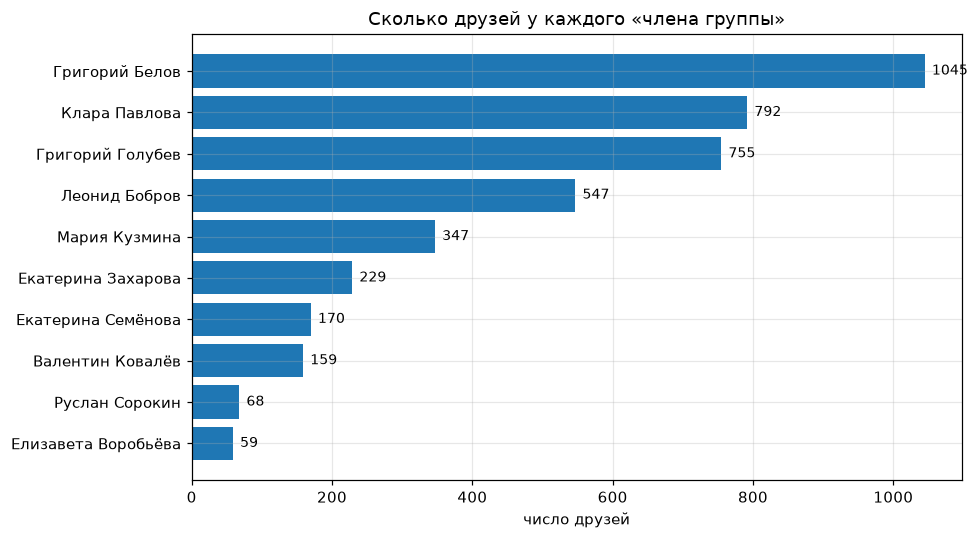

Елизавета Воробьёва      59
Руслан Сорокин           68
Валентин Ковалёв        159
Екатерина Семёнова      170
Екатерина Захарова      229
Мария Кузмина           347
Леонид Бобров           547
Григорий Голубев        755
Клара Павлова           792
Григорий Белов         1045
Name: друзей, dtype: int64

In [2]:
n_friends = pd.Series({m: G.degree(m) for m in members}, name='друзей').sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(n_friends.index, n_friends)
ax.set_title('Сколько друзей у каждого «члена группы»')
ax.set_xlabel('число друзей')
for i, v in enumerate(n_friends):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
fig.tight_layout()
plt.show()
n_friends


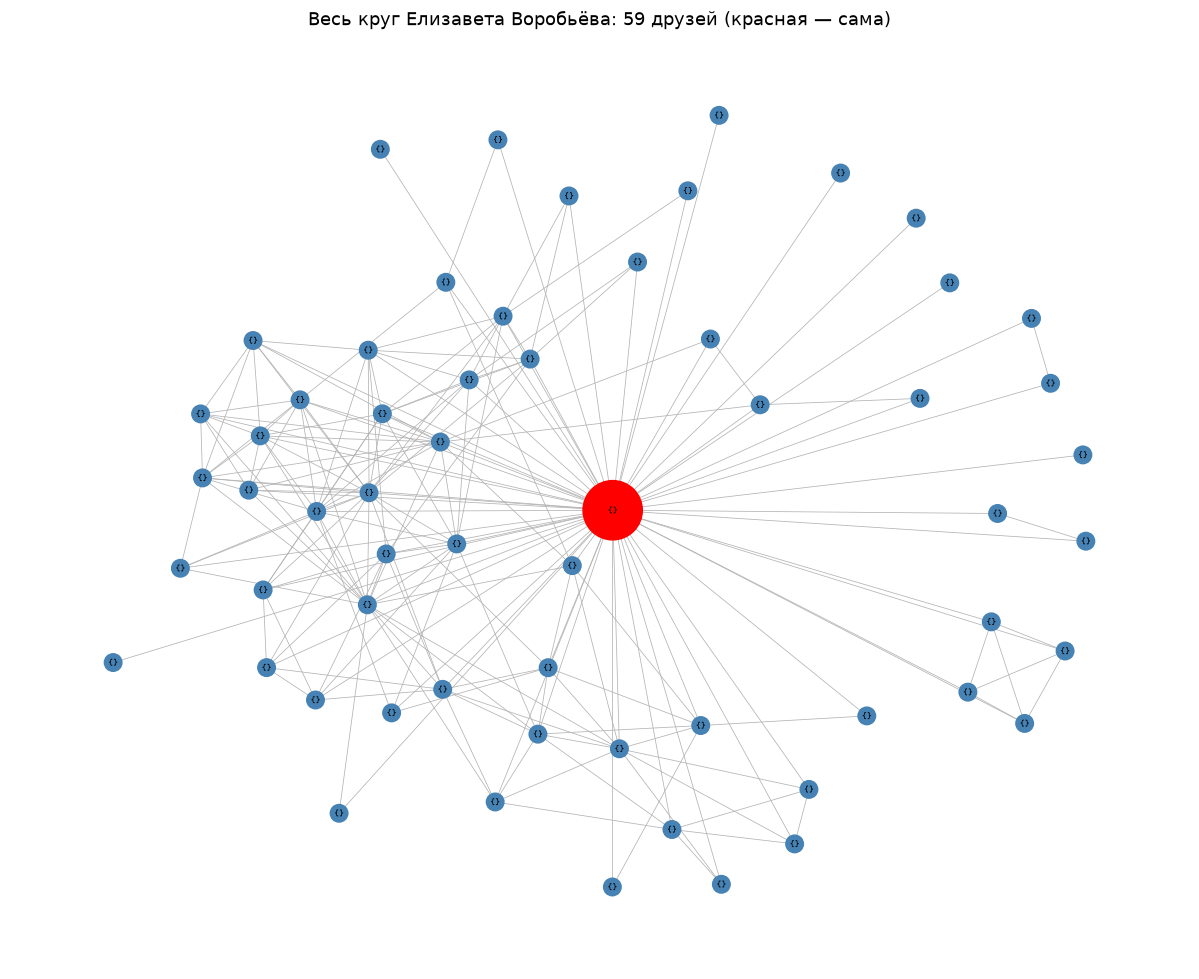

In [3]:
smallest = n_friends.idxmin()
circle = set(G.neighbors(smallest)) | {smallest}
sub = G.subgraph(circle)
pos = nx.spring_layout(sub, seed=SEED)
fig, ax = plt.subplots(figsize=(11, 9))
nx.draw(sub, pos, ax=ax,
        node_color=['red' if n == smallest else 'steelblue' for n in sub.nodes],
        node_size=[1500 if n == smallest else 130 for n in sub.nodes],
        edge_color='0.7', width=0.5)
nx.draw_networkx_labels(sub, pos, ax=ax, labels=sub.nodes, font_size=5.5)
ax.set_title(f'Весь круг {smallest}: {len(circle) - 1} друзей (красная — сама)')
plt.tight_layout()
plt.show()


### Вся сеть целиком

Все 10 «членов группы» вместе со своими друзьями образуют одну сеть: **4039 человек и 88234 пары друзей**. Сеть связная: от любого человека до любого другого можно «дойти» по цепочке друзей.


Друзей у человека: у половины — не больше 25, у самого «общительного» — 1045 (это Григорий Белов).
В среднем между любыми двумя людьми в сети 3.7 шага дружбы: «степени разделённости» здесь не шесть, а около четырёх.


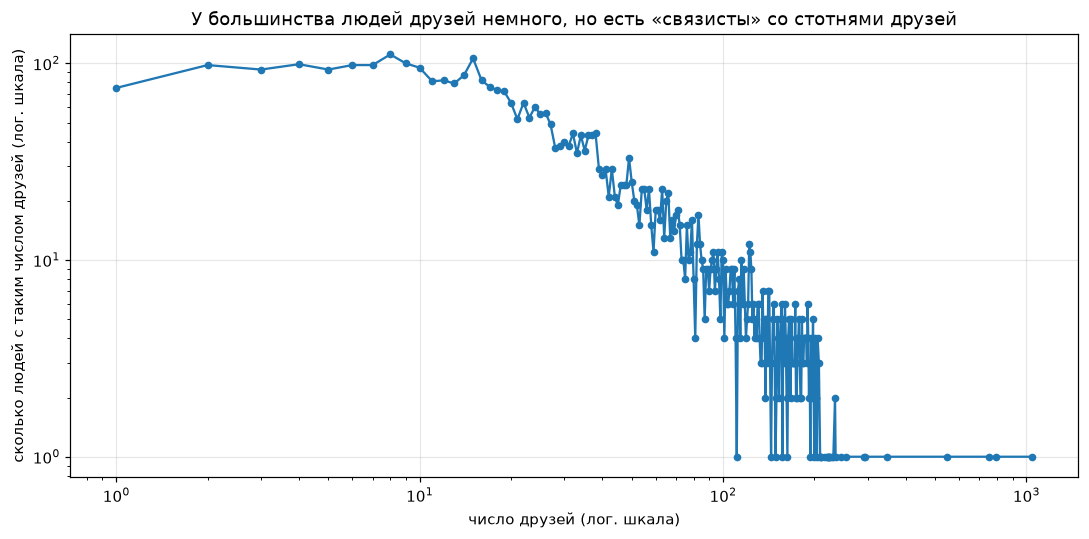

In [4]:
deg = pd.Series(dict(G.degree()))
avg_steps = nx.average_shortest_path_length(G)
print(f'Друзей у человека: у половины — не больше {int(deg.median())}, '
      f'у самого «общительного» — {deg.max()} (это {deg.idxmax()}).')
print(f'В среднем между любыми двумя людьми в сети {avg_steps:.1f} шага дружбы: '
      f'«степени разделённости» здесь не шесть, а около четырёх.')

fig, ax = plt.subplots(figsize=(10, 5))
vals, cnt = np.unique(deg.values, return_counts=True)
ax.loglog(vals, cnt, 'o-', ms=4)
ax.set_xlabel('число друзей (лог. шкала)')
ax.set_ylabel('сколько людей с таким числом друзей (лог. шкала)')
ax.set_title('У большинства людей друзей немного, но есть «связисты» со стотнями друзей')
fig.tight_layout()
plt.show()


## 2. Задание: кто самый «центральный» из членов группы?

Единого ответа на вопрос «кто самый важный человек» не бывает — всё зависит от того, что мы имеем в виду. Берём три мерки (формулы — со слайдов курса):

**1. «Мост» — betweenness (центральность по посредничеству).**
Сколько кратчайших путей между людьми проходит через данного человека. Кто-то, кто связывает две компании, дружащие только через него, — мост: уберите его, и компании «разъедутся». Чем больше путей идёт через человека, тем выше балл.
$$C_B(i) = \sum_{s \neq i \neq t} \frac{\sigma_{st}(i)}{\sigma_{st}}$$

**2. «Рядом со всеми» — closeness (центральность по близости).**
Сколько шагов от человека в среднем до всех остальных в сети. Чем меньше «удалённость» до всех, тем выше балл — такой человек «рядом со всеми».
$$C_C(i) = \frac{1}{\sum_j d_{ij}}$$

**3. «В окружении важных» — eigenvector (центральность по собственному вектору).**
Важность человека зависит от важности его друзей: дружба с «важными» людьми сама делает человека важным. Балл учитывает всю сеть: у кого друзья сами «связисты», тот и выше.
$$x_i = \frac{1}{\lambda} \sum_j a_{ij} x_j$$

Баллы считаем для **всех 4039 человек**, но отчёт — по заданию — только о **10 членах группы**.


In [5]:
t0 = time.time()
betweenness = nx.betweenness_centrality(G)
print(f'«мост» посчитан за {time.time() - t0:.0f} с')
t0 = time.time()
closeness = nx.closeness_centrality(G)
print(f'«рядом со всеми» посчитан за {time.time() - t0:.0f} с')
t0 = time.time()
eigenvector = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-8)
print(f'«в окружении важных» посчитан за {time.time() - t0:.0f} с')

res = pd.DataFrame({
    'друзей': [G.degree(m) for m in members],
    '«мост» (betweenness)': [round(betweenness[m], 4) for m in members],
    '«рядом со всеми» (closeness)': [round(closeness[m], 4) for m in members],
    '«в окружении важных» (eigenvector)': [f'{eigenvector[m]:.5f}' for m in members],
}, index=members)
res.index.name = 'член группы'
for col, full in [
    ('«мост» (betweenness)', pd.Series(betweenness)),
    ('«рядом со всеми» (closeness)', pd.Series(closeness)),
]:
    res[col + ' — место'] = [
        f'сильнее, чем {100 * (full < res.loc[m, col]).mean():.1f}% людей' for m in members]
res['«в окружении важных» — место'] = [
    f'сильнее, чем {100 * (pd.Series(eigenvector) < float(res.loc[m, "«в окружении важных» (eigenvector)"])).mean():.1f}% людей'
    for m in members]
res


«мост» посчитан за 64 с


«рядом со всеми» посчитан за 20 с


«в окружении важных» посчитан за 1 с


,друзей,«мост» (betweenness),«рядом со всеми» (closeness),«в окружении важных» (eigenvector),«мост» (betweenness) — место,«рядом со всеми» (closeness) — место,«в окружении важных» — место
член группы,,,,,,,
Мария Кузмина,347,0.1463,0.3533,0.00003,"сильнее, чем 99.9% людей","сильнее, чем 99.3% людей","сильнее, чем 79.9% людей"
Григорий Белов,1045,0.4805,0.4597,0.00017,"сильнее, чем 100.0% людей","сильнее, чем 100.0% людей","сильнее, чем 81.3% людей"
Екатерина Захарова,229,0.0380,0.3699,0.00001,"сильнее, чем 99.7% людей","сильнее, чем 99.8% людей","сильнее, чем 74.2% людей"
Валентин Ковалёв,159,0.0476,0.3695,0.00001,"сильнее, чем 99.7% людей","сильнее, чем 99.8% людей","сильнее, чем 74.2% людей"
Екатерина Семёнова,170,0.0297,0.2169,0.00000,"сильнее, чем 99.6% людей","сильнее, чем 6.4% людей","сильнее, чем 0.0% людей"
Руслан Сорокин,68,0.1153,0.2712,0.00000,"сильнее, чем 99.8% людей","сильнее, чем 44.4% людей","сильнее, чем 0.0% людей"
Клара Павлова,792,0.3378,0.3936,0.00001,"сильнее, чем 100.0% людей","сильнее, чем 99.9% людей","сильнее, чем 74.2% людей"
Григорий Голубев,755,0.2293,0.3509,0.09541,"сильнее, чем 99.9% людей","сильнее, чем 99.3% людей","сильнее, чем 100.0% людей"
Леонид Бобров,547,0.2361,0.3144,0.00000,"сильнее, чем 99.9% людей","сильнее, чем 74.0% людей","сильнее, чем 0.0% людей"


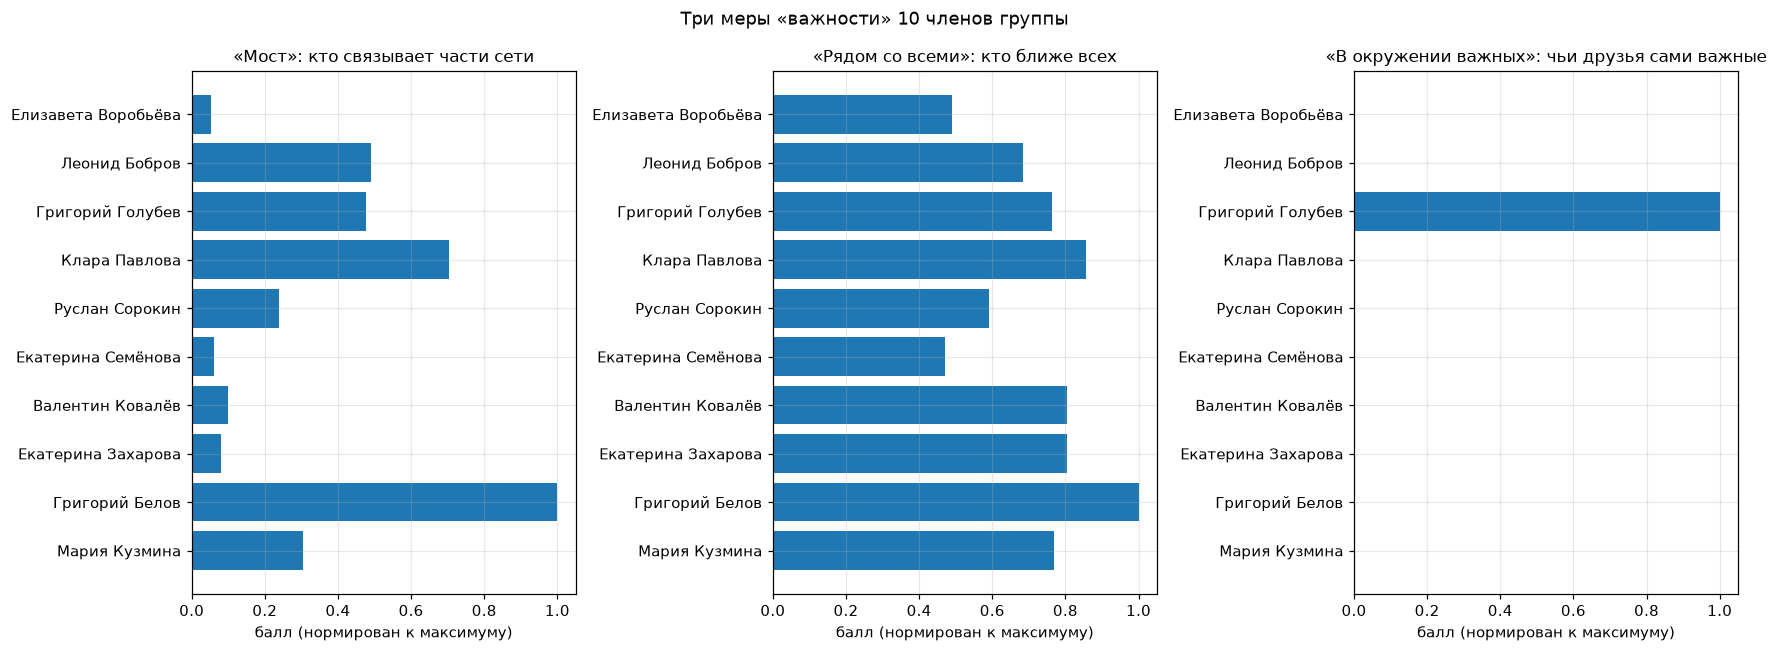

In [6]:
cols = [
    ('«мост» (betweenness)', '«Мост»: кто связывает части сети'),
    ('«рядом со всеми» (closeness)', '«Рядом со всеми»: кто ближе всех'),
    ('«в окружении важных» (eigenvector)', '«В окружении важных»: чьи друзья сами важные'),
]
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
for a, (col, title) in zip(ax, cols):
    v = res[col].astype(float)
    a.barh(res.index, v / v.max())
    a.set_title(title, fontsize=11)
    a.set_xlabel('балл (нормирован к максимуму)')
fig.suptitle('Три меры «важности» 10 членов группы')
fig.tight_layout()
plt.show()


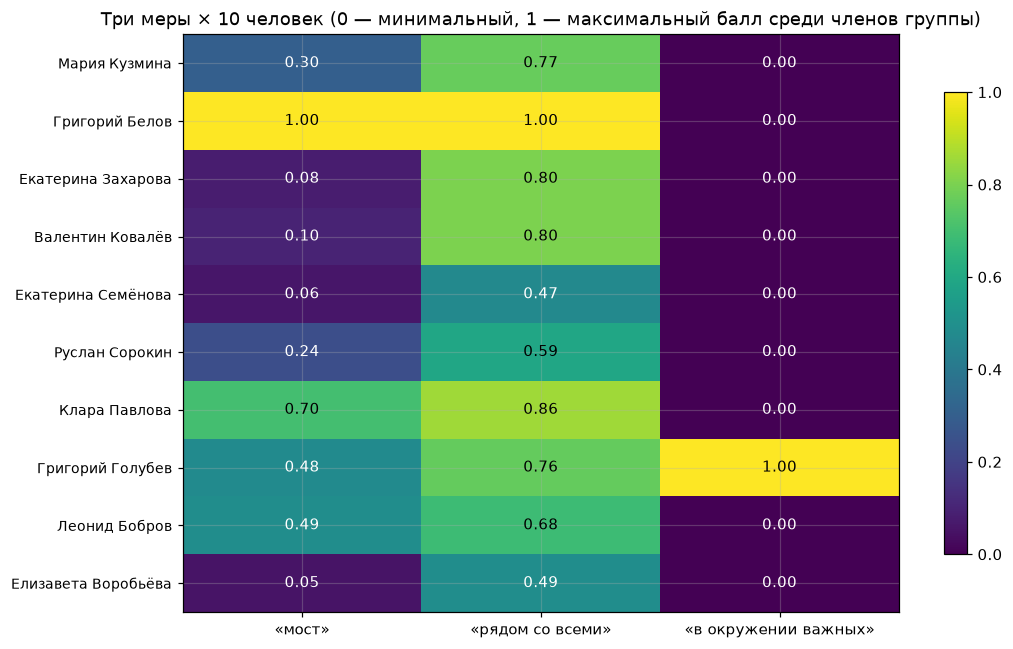

In [7]:
M = res[['«мост» (betweenness)', '«рядом со всеми» (closeness)', '«в окружении важных» (eigenvector)']].astype(float)
Mn = (M / M.max()).values
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(Mn, aspect='auto', cmap='viridis')
ax.set_xticks(range(3), ['«мост»', '«рядом со всеми»', '«в окружении важных»'], fontsize=10)
ax.set_yticks(range(len(M)), M.index, fontsize=9)
for i in range(len(M)):
    for j in range(3):
        ax.text(j, i, f'{Mn[i, j]:.2f}', ha='center', va='center',
                color='white' if Mn[i, j] < 0.5 else 'black')
ax.set_title('Три меры × 10 человек (0 — минимальный, 1 — максимальный балл среди членов группы)')
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()


### Вывод простыми словами

- **«Мост»**: лидер — **Григорий Белов** (у него и самый большой круг — 1045 друзей): через его круг проходит больше всего коротких путей между людьми сети. Дальше — Клара Павлова (792 друга) и Леонид Бобров (547).
- **«Рядом со всеми»**: опять **Григорий Белов** — от его круга до почти всех в сети 1–2 шага. У членов группы с маленькими кругами всё наоборот: **Екатерина Семёнова** (170 друзей) и **Елизавета Воробьёва** (59) живут в «замкнутом мирке», далёком от остальной сети, — по этой мере они сильнее лишь ~6–7% всех людей.
- **«В окружении важных»**: выбивается **Григорий Голубев** — **1-е место среди всех 4039 человек**. Его круг не самый большой, но его друзья сами «связисты» — это и поднимает его балл. У всех остальных членов группы он в сотни раз ниже.

**Итого:** самый центральный член группы — **Григорий Белов** (1-е место по двум мерам из трёх, 2-е по третьей). Меры меряют разное: «мост» и «рядом со всеми» здесь почти следует за размером круга (у кого друзей больше — тот «важнее»), а «в окружении важных» показывает **качество** круга — с кем именно человек дружит.

**Оговорки.** (1) Вместо реального VK использован публичный датасет Ego Facebook (2009): методика для VK точно такая же — собрать друзей и друзей-друзей членов группы, построить сеть, посчитать эти же три меры. (2) «Члены группы» в сети — «хабы» по построению (каждый дружит со всем своим кругом), поэтому «мост» и «рядом со всеми» сильно зависят от размера круга.
